In [42]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [43]:
#state name
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi:float
    category: str
    

In [44]:
def calculate_bmi(state:BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi= weight/(height**2)

    state['bmi']= round(bmi,2)

    return state


In [48]:
def lable_bmi(state:BMIState)->BMIState:
    bmi=state['bmi']
    if bmi < 18.5:
        state["category"] = "underWeight"
    elif 18.5<=bmi<25:
        state["category"]="Normal"
    elif 25<=bmi<30:
        state["category"]="OverWeight"
    else:
        state["category"]="Obese"
    return state

In [50]:
# define your graph
graph= StateGraph(BMIState)

# addnotes to graph 
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node('lable_bmi', lable_bmi)
# add edges to graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','lable_bmi')
graph.add_edge('lable_bmi',END)

# complie the graph
workflow = graph.compile()


In [51]:
# execute graph
initial_state={'weight_kg':80,'height_m':1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'OverWeight'}


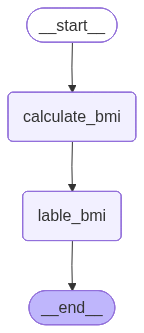

In [ ]:
# print graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())